In [1]:
print('Hello')

Hello


In [30]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import export_text
#Load iris dataset
iris = load_iris()

X = iris.data[:,:2]
#print(X) #we only take the first two features.
y = iris.target
#print(y)
#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
#Train a DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train, y_train)
#Check accuracy
y_pred=clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.8


In [31]:
iris.feature_names[:2]
#iris.target_names

['sepal length (cm)', 'sepal width (cm)']

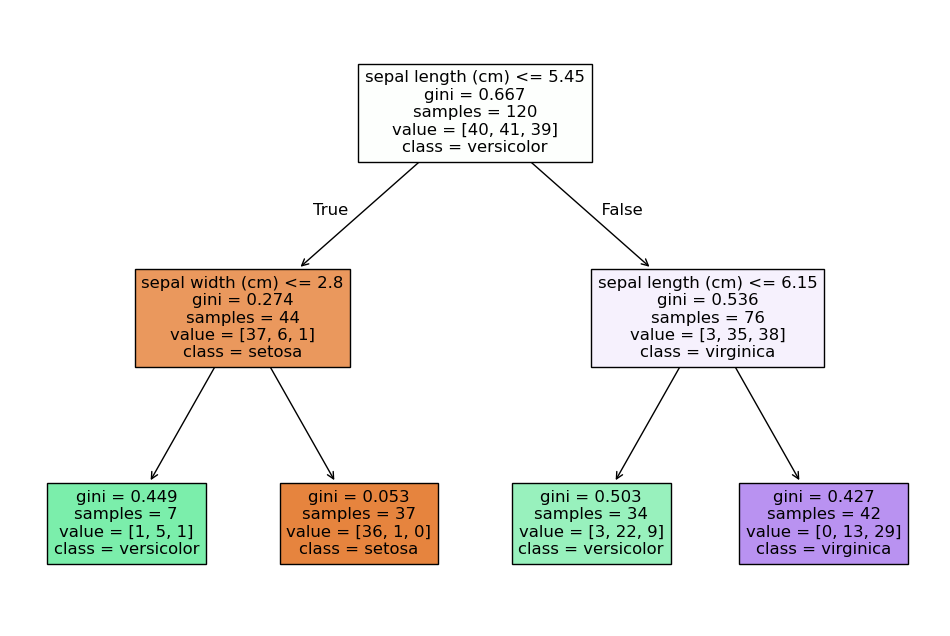

Text(0, 0.5, 'Senal width')

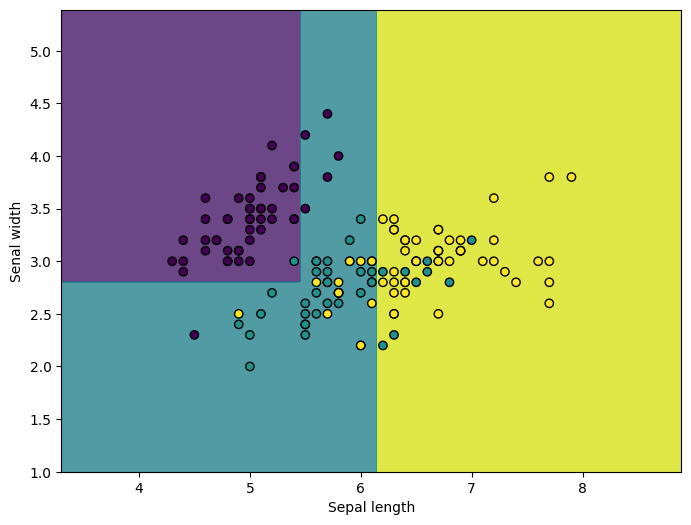

In [34]:
#Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=iris.feature_names[:2], class_names=iris.target_names)
plt.show()
#Plot the decision boundary
plt.figure(figsize=(8, 6))
x_min, x_max = X[:, 0].min()-1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.xlabel('Sepal length')
plt.ylabel('Senal width') 

In [37]:
r = export_text(clf, feature_names=['sepal_length','sepal_width'])
print(r)

|--- sepal_length <= 5.45
|   |--- sepal_width <= 2.80
|   |   |--- class: 1
|   |--- sepal_width >  2.80
|   |   |--- class: 0
|--- sepal_length >  5.45
|   |--- sepal_length <= 6.15
|   |   |--- class: 1
|   |--- sepal_length >  6.15
|   |   |--- class: 2



In [42]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np
#Generate a non Linear dataset bised on the sine function
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - np.random.rand(16)) # add some noise to the data

#Split inte training and Lesting datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Fit Decision Tree regressor
regressor = DecisionTreeRegressor(max_depth=2)
regressor.fit(X_train, y_train)

# To plot the regression curve, we'll sort the x values and predict values for the sorted
X_grid = np.arange(min(X), max(X), 0.01)[:, np.newaxis]
y_grid = regressor.predict(X_grid)
# Plot the training data and the regression curve
plt.scatter(X_train, y_train, color=red, label='data')
plt.plot(X_grid, y_grid, color="blue", label="prediction")
plt.title('Decision Tree Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars